In [ ]:
# | eval: false

In [ ]:
import sys
sys.path.append("..")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from ddpm_lib.data_loaders import prepare_dataloaders,get_nifty_regime_data,niftyriskdataset,compute_regime_score
from ddpm_lib.diffusion_utils import FiLMTabularDDPM,TabularDDPM
from ddpm_lib.noisify_time_emb import cosine_beta_scheduler,timestep_embedding,noisify
from ddpm_lib.models import FiLMLayer,f_net
from tqdm.auto import tqdm

c:\Users\GARVIT\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
T = 200
betas = cosine_beta_scheduler(T)
alphas = 1-betas
alphas_bar = torch.cumprod(torch.from_numpy(alphas).float(),dim=0)

In [ ]:
diffusion_model = FiLMTabularDDPM(d_in=1,model=f_net,cond_in_classes=2,continious_conditioning_in=8)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=3e-4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
diffusion_model.to(device)
alphas_bar = alphas_bar.to(device)
print(f"Training on device: {device}")

Training on device: cpu


In [ ]:
risk_df = get_nifty_regime_data()
risk_df['regime_score'] = compute_regime_score(risk_df)
risk_df['regime_score'] = risk_df['regime_score'].fillna(0.5)
risk_df['regime'] = (risk_df['regime_score'] > 0.5).astype(int)

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed



In [ ]:
train_dl, val_dl, condition_df, scaler_x, scaler_cond,val_df = prepare_dataloaders(
    risk_df,
    batch_size=64,
    train_size=0.80,
    val_size=0.10
)

print(f"\nDataLoader batch info:")
print(f"  Train batches: {len(train_dl)}")
print(f"  Validation batches: {len(val_dl)}")
print(f"\nConditioning dataframe shape: {condition_df.shape}")
print(f"Conditioning date range: {condition_df.index[0]} to {condition_df.index[-1]}")

Data split:
  Train: 2037 samples (80.0%)
  Validation: 255 samples (10.0%)
  Conditioning: 255 samples (10.0%)

DataLoader batch info:
  Train batches: 32
  Validation batches: 4

Conditioning dataframe shape: (255, 12)
Conditioning date range: 2025-02-14 00:00:00 to 2026-02-26 00:00:00

DataLoader batch info:
  Train batches: 32
  Validation batches: 4

Conditioning dataframe shape: (255, 12)
Conditioning date range: 2025-02-14 00:00:00 to 2026-02-26 00:00:00


In [ ]:
from tqdm.auto import tqdm

num_epochs = 250
diffusion_model.train()
drop_prob_cat  = 0.15
drop_prob_cont = 0.10
null_label     = 0

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    progress_bar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch in progress_bar:
        x0, c, cond = batch

        x0   = x0.to(device)
        c    = c.to(device)
        cond = cond.to(device)

        if x0.dim() == 1:
            x0 = x0.unsqueeze(1)

        B = c.shape[0]

        # ----------------------------------------------------------
        # CFG dropout — condition masking only, no extra fwd passes
        # ----------------------------------------------------------
        drop_cat  = torch.rand(B, device=device) < drop_prob_cat
        drop_cont = torch.rand(B, device=device) < drop_prob_cont

        c    = c.clone()
        cond = cond.clone()

        c[drop_cat]    = null_label  
        cond[drop_cont] = 0.0        

        # ----------------------------------------------------------
        # Standard DDPM forward pass — single model call
        # ----------------------------------------------------------
        xt, t, eps = noisify(T, x0, alphas_bar)

        eps_pred = diffusion_model(xt, c, cond, t.float())  

        loss = F.smooth_l1_loss(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion_model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / num_batches

    # --- Validation loss ---
    diffusion_model.eval()
    val_loss, val_batches = 0.0, 0
    with torch.no_grad():
        for batch in val_dl:
            x0v, cv, condv = batch
            x0v, cv, condv = x0v.to(device), cv.to(device), condv.to(device)
            if x0v.dim() == 1:
                x0v = x0v.unsqueeze(1)
            xtv, tv, epsv = noisify(T, x0v, alphas_bar)
            eps_predv = diffusion_model(xtv, cv, condv, tv.float())
            val_loss += F.smooth_l1_loss(eps_predv, epsv).item()
            val_batches += 1
    avg_val_loss = val_loss / val_batches
    diffusion_model.train()

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_loss:.6f} | Val: {avg_val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("\nTraining completed!")

Epoch 1/250: 100%|██████████| 32/32 [00:04<00:00,  7.33it/s, loss=0.398]



Epoch 1/250 | Train: 0.418867 | Val: 0.439069 | LR: 3.00e-04


Epoch 2/250: 100%|██████████| 32/32 [00:02<00:00, 13.52it/s, loss=0.265]



Epoch 2/250 | Train: 0.319781 | Val: 0.240283 | LR: 3.00e-04


Epoch 3/250: 100%|██████████| 32/32 [00:02<00:00, 10.94it/s, loss=0.253]



...

Epoch 248/250 | Train: 0.189130 | Val: 0.279868 | LR: 4.74e-08


Epoch 249/250: 100%|██████████| 32/32 [00:06<00:00,  5.28it/s, loss=0.173]


Epoch 249/250 | Train: 0.186181 | Val: 0.253084 | LR: 1.18e-08


Epoch 250/250: 100%|██████████| 32/32 [00:02<00:00, 13.97it/s, loss=0.148]


Epoch 250/250 | Train: 0.187095 | Val: 0.288022 | LR: 0.00e+00

Training completed!


In [ ]:
#| default_exp samplers

In [ ]:
#| export
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import numpy as np


In [ ]:
#| export
def sample_n_samples(
    n_samples, model, alphas, betas, scaler_x,
    guidance_scale_cat=1.5,
    guidance_scale_cont=0.5,
    null_label=0,
    regime=1,              
    continuous_cond=None, 
):
    global alphas_bar, T
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    alphas_t = torch.from_numpy(alphas).float().to(device)
    betas_t  = torch.from_numpy(betas).float().to(device)

    model.eval()
    model.to(device)

    xt = torch.randn((n_samples, 1), device=device)
    c_cond = torch.full((n_samples,), regime, device=device, dtype=torch.long)

    if continuous_cond is None:
        continuous_cond = torch.zeros((n_samples, 8), device=device, dtype=torch.float32)
    else:
        continuous_cond = continuous_cond.to(device).repeat(n_samples, 1)

    null_c    = torch.full_like(c_cond, null_label)
    null_cond = torch.zeros_like(continuous_cond)

    with torch.no_grad():
        for t in tqdm(reversed(range(T)), desc="Sampling", total=T):
            t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)

            alpha_t      = alphas_t[t].unsqueeze(0).unsqueeze(1)
            beta_t       = betas_t[t].unsqueeze(0).unsqueeze(1)
            alpha_bar_t  = alphas_bar[t].unsqueeze(0).unsqueeze(1)

            sqrt_alpha_t             = torch.sqrt(alpha_t)
            sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar_t)

            t_float = t_tensor.float()
            eps_uncond = model(xt, null_c,  null_cond,        t_float)
            eps_cat    = model(xt, c_cond,  null_cond,        t_float)
            eps_cont   = model(xt, null_c,  continuous_cond,  t_float)

            eps_guided = (
                eps_uncond
                + guidance_scale_cat  * (eps_cat  - eps_uncond)
                + guidance_scale_cont * (eps_cont - eps_uncond)
            )

            mean_t = (xt - (beta_t / sqrt_one_minus_alpha_bar) * eps_guided) / sqrt_alpha_t

            if t > 0:
                z  = torch.randn_like(xt)
                xt = mean_t + torch.sqrt(beta_t) * z
            else:
                xt = mean_t

    return scaler_x.inverse_transform(xt.cpu().numpy())

In [ ]:
#| export
def sample_with_conditions(
    condition_row, n_samples, model, alphas, betas, scaler_x, scaler_cond,
    # CFG params
    guidance_scale_cat=0.5,
    guidance_scale_cont=0.2,
    null_label=0,
    alphas_bar_in=None,  # pass explicitly to avoid stale global
    temperature=1,     # >1.0 widens distribution variance
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(42)
    np.random.seed(42)
    _ab = (alphas_bar_in if alphas_bar_in is not None else alphas_bar).to(device)

    alphas_t = torch.from_numpy(alphas).float().to(device)
    betas_t  = torch.from_numpy(betas).float().to(device)

    model.eval()
    model.to(device)

    xt = torch.randn((n_samples, 1), device=device)

    print(f"Sampling with REAL conditions:")
    print(f"  Regime: {condition_row['regime']}")
    print(f"  Regime: {condition_row['regime']}")
    print(f"  Realized Vol: {condition_row['realized_vol']:.4f}")
    print(f"  VIX: {condition_row['VIX']:.2f}")
    print(f"  RSI: {condition_row['RSI']:.2f}")
    print(f"  Skew: {condition_row['skew']:.3f}")
    print(f"  guidance_scale_cat={guidance_scale_cat}, guidance_scale_cont={guidance_scale_cont}")

    # --- Conditions ---
    regime = int(condition_row['regime'])
    c_cond = torch.full((n_samples,), regime+1, device=device, dtype=torch.long)

    continuous_features = np.array([
        condition_row['realized_vol'],
        condition_row['VIX'],
        condition_row['RSI'],
        condition_row['skew'],
        condition_row['kurtosis'],
        condition_row['vol_spike'],
        condition_row['RSI_velocity'],
        condition_row['regime_score']
    ]).reshape(1, -1)

    continuous_features_scaled = scaler_cond.transform(continuous_features)
    continuous_cond = torch.tensor(
        continuous_features_scaled, device=device, dtype=torch.float32
    ).repeat(n_samples, 1)

    # --- Null tensors (defined once, reused every step) ---
    null_c    = torch.full_like(c_cond, null_label)
    null_cond = torch.zeros_like(continuous_cond)

    # --- Reverse diffusion ---
    with torch.no_grad():
        for t in tqdm(reversed(range(T)), desc="Sampling", total=T):
            t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)

            alpha_t       = alphas_t[t].unsqueeze(0).unsqueeze(1)
            beta_t        = betas_t[t].unsqueeze(0).unsqueeze(1)
            alpha_bar_t   = _ab[t].unsqueeze(0).unsqueeze(1)

            sqrt_alpha_t             = torch.sqrt(alpha_t)
            sqrt_one_minus_alpha_bar = torch.sqrt(1. - alpha_bar_t).clamp(min=1e-5)

            # --- CFG: 3 forward passes ---
            t_float = t_tensor.float()
            eps_uncond = model(xt, null_c,  null_cond,       t_float)  # neither
            eps_cat    = model(xt, c_cond,  null_cond,       t_float)  # only regime
            eps_cont   = model(xt, null_c,  continuous_cond, t_float)  # only continuous

            eps_guided = (
                eps_uncond
                + guidance_scale_cat  * (eps_cat  - eps_uncond)
                + guidance_scale_cont * (eps_cont - eps_uncond)
            ).clamp(-3.0, 3.0)
            # --- Reverse step ---
            mean_t = (xt - (beta_t / sqrt_one_minus_alpha_bar) * eps_guided) / sqrt_alpha_t

            if t > 0:
                z  = torch.randn_like(xt)
                xt = mean_t + temperature * torch.sqrt(beta_t) * z
                xt = xt.clamp(-10.0, 10.0)  # prevent runaway values
            else:
                xt = mean_t

    return scaler_x.inverse_transform(xt.cpu().numpy())

In [ ]:
n_samples = 5000
condition_row_regime0 = condition_df[condition_df['regime'] == 0].iloc[-1] # Taking the last regime 0 entry from the whole dataset for demonstration
torch.manual_seed(42)
np.random.seed(42)

generated_samples = sample_with_conditions(
    condition_row_regime0, n_samples, diffusion_model, alphas, betas, scaler_x, scaler_cond,
    alphas_bar_in=alphas_bar,
    guidance_scale_cat=2.5,
    guidance_scale_cont=1.5,
)

print(f"Shape of generated samples for regime 0: {generated_samples.shape}")

print("\nFirst 20 generated samples for regime 0:")
print(generated_samples[:20])

Sampling with REAL conditions:
  Regime: 0.0
  Regime: 0.0
  Realized Vol: 0.1393
  VIX: 13.49
  RSI: 46.20
  Skew: 0.542
  guidance_scale_cat=2.5, guidance_scale_cont=1.5


c:\Users\GARVIT\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Sampling: 100%|██████████| 200/200 [04:32<00:00,  1.36s/it]

Shape of generated samples for regime 0: (5000, 1)

First 20 generated samples for regime 0:
[[ 0.10582078]
 [ 0.10675186]
 [ 0.10638345]
 [-0.10446049]
 [ 0.10591489]
 [-0.10603272]
 [ 0.10643434]
 [-0.10630709]
 [-0.1058395 ]
 [ 0.10721357]
 [-0.10390373]
 [-0.1057428 ]
 [-0.10607738]
 [-0.10617026]
 [-0.10533406]
 [ 0.1048345 ]
 [ 0.10532905]
 [-0.10580824]
 [-0.10384768]
 [ 0.1071417 ]]


Number of generated samples: 5000
Number of NaN values in generated samples: 0
Number of infinite values in generated samples: 0

Number of actual regime 0 returns: 249
Number of NaN values in actual regime 0 returns: 0
Number of infinite values in actual regime 0 returns: 0

Summary statistics of generated samples:
count    5000.000000
mean        0.008245
std         0.105616
min        -0.106307
25%        -0.105579
50%         0.104971
75%         0.106932
max         0.107295
dtype: float64

Summary statistics of actual regime 0 returns:
count    249.000000
mean       0.000102
std        0.007085
min       -0.032970
25%       -0.003805
50%        0.000129
75%        0.004515
max        0.037472
dtype: float64

Summary statistics of generated samples:
count    5000.000000
mean        0.008245
std         0.105616
min        -0.106307
25%        -0.105579
50%         0.104971
75%         0.106932
max         0.107295
dtype: float64

Summary statistics of actual regime 0 returns:
cou

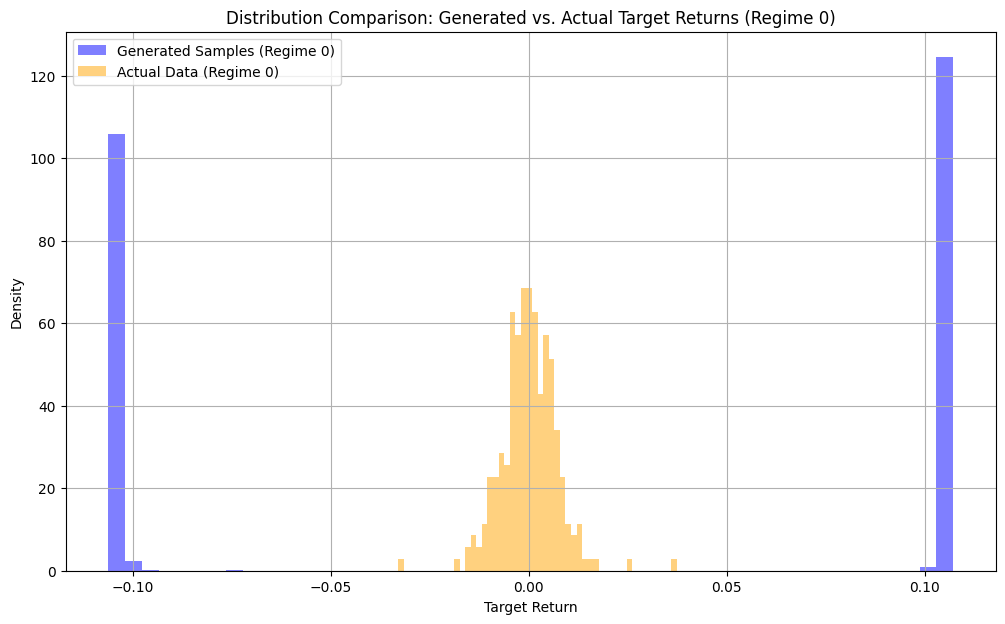

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
valid_generated_samples = generated_samples.flatten()
print(f"Number of generated samples: {len(valid_generated_samples)}")
print(f"Number of NaN values in generated samples: {np.isnan(valid_generated_samples).sum()}")
print(f"Number of infinite values in generated samples: {np.isinf(valid_generated_samples).sum()}")
valid_generated_samples = valid_generated_samples[np.isfinite(valid_generated_samples)]
actual_regime0_returns = condition_df[condition_df['regime'] == 0]['target_return'].dropna().values

print(f"\nNumber of actual regime 0 returns: {len(actual_regime0_returns)}")
print(f"Number of NaN values in actual regime 0 returns: {np.isnan(actual_regime0_returns).sum()}")
print(f"Number of infinite values in actual regime 0 returns: {np.isinf(actual_regime0_returns).sum()}")
actual_regime0_returns = actual_regime0_returns[np.isfinite(actual_regime0_returns)]

plt.figure(figsize=(12, 7))
if len(valid_generated_samples) > 0:
    plt.hist(valid_generated_samples, bins=50, density=True, alpha=0.5, label='Generated Samples (Regime 0)', color='blue')
    print("\nSummary statistics of generated samples:")
    print(pd.Series(valid_generated_samples).describe())
else:
    print("\nWarning: All generated samples are NaN or infinite. Check the model and sampling process.")
if len(actual_regime0_returns) > 0:
    plt.hist(actual_regime0_returns, bins=50, density=True, alpha=0.5, label='Actual Data (Regime 0)', color='orange')
    print("\nSummary statistics of actual regime 0 returns:")
    print(pd.Series(actual_regime0_returns).describe())
else:
    print("\nWarning: No valid actual regime 0 returns found.")

plt.title('Distribution Comparison: Generated vs. Actual Target Returns (Regime 0)')
plt.xlabel('Target Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()